In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL   #image processing capabilities-Pillow libraries
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir=".", untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
data_dir

'./datasets/flower_photos'

In [5]:
# to convert data directory into pathlib

import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [6]:
len_img = len(list(data_dir.glob('*/*/*.jpg')))

In [7]:
len_img

3670

In [8]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/494803274_f84f21d53a.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7251352826_69b62cba2c_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3873271620_1d9d314f01_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7376473742_532364cee5_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9164924345_6b63637acf.jpg')]

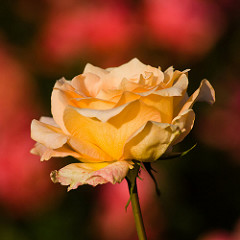

In [9]:
PIL.Image.open(str(roses[1]))

In [10]:
tulips = list(data_dir.glob('*/tulips/*'))
tulips[:5]

[PosixPath('datasets/flower_photos/flower_photos/tulips/19413898445_69344f9956_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/7166626128_8e0983ac8e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/4525067924_177ea3bfb4.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/113902743_8f537f769b_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/tulips/18378581986_5cd1494d08_n.jpg')]

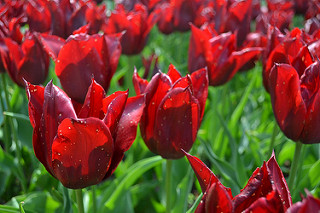

In [11]:
PIL.Image.open(str(tulips[1]))

In [12]:
flowers_images_dict = {
    'roses': list(data_dir.glob('*/roses/*')),
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*')),

}

In [13]:
flower_labels_dct = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}


In [14]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

array([[[ 34,  58,  24],
        [ 35,  56,  23],
        [ 40,  59,  26],
        ...,
        [ 50,  74,  74],
        [ 47,  68,  65],
        [ 37,  59,  54]],

       [[ 42,  56,  32],
        [ 38,  52,  28],
        [ 39,  52,  28],
        ...,
        [ 45,  71,  71],
        [ 46,  72,  66],
        [ 46,  70,  62]],

       [[ 42,  45,  30],
        [ 43,  46,  31],
        [ 44,  49,  34],
        ...,
        [ 37,  68,  65],
        [ 42,  70,  64],
        [ 48,  75,  65]],

       ...,

       [[216, 206, 182],
        [228, 214, 191],
        [249, 229, 204],
        ...,
        [ 99,  71, 131],
        [107,  76, 137],
        [117,  84, 145]],

       [[211, 193, 176],
        [217, 200, 181],
        [223, 209, 186],
        ...,
        [104,  81, 143],
        [111,  89, 148],
        [115,  95, 154]],

       [[200, 179, 171],
        [213, 194, 181],
        [223, 207, 190],
        ...,
        [100,  85, 146],
        [ 96,  84, 142],
        [ 86,  79, 136]]], dtype=uint8)
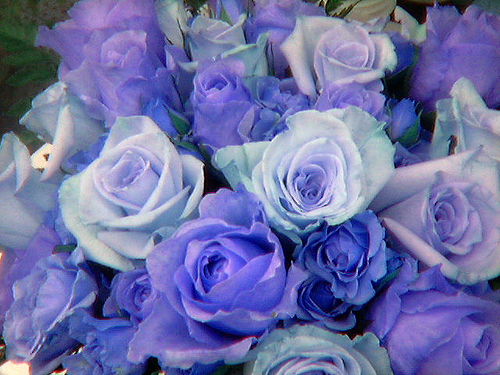

In [15]:
img

In [16]:
img.shape

(375, 500, 3)

In [17]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [18]:
X,y = [],[]

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flower_labels_dct[flower_name])

In [19]:
X

[array([[[ 37,  54,  26],
         [ 44,  54,  29],
         [ 53,  57,  36],
         ...,
         [ 47,  64,  63],
         [ 39,  65,  69],
         [ 46,  69,  64]],
 
        [[ 46,  47,  34],
         [ 49,  55,  38],
         [ 51,  58,  41],
         ...,
         [ 51,  71,  70],
         [ 42,  74,  79],
         [ 43,  70,  66]],
 
        [[ 45,  50,  31],
         [ 42,  51,  29],
         [ 49,  58,  34],
         ...,
         [ 58,  73,  80],
         [ 49,  73,  83],
         [ 52,  74,  74]],
 
        ...,
 
        [[239, 235, 205],
         [254, 245, 212],
         [253, 244, 206],
         ...,
         [100, 101, 163],
         [ 95,  96, 152],
         [ 94,  92, 143]],
 
        [[231, 217, 197],
         [255, 237, 211],
         [254, 240, 209],
         ...,
         [ 98,  81, 140],
         [101,  78, 137],
         [110,  82, 141]],
 
        [[214, 196, 180],
         [230, 219, 191],
         [249, 230, 198],
         ...,
         [ 95,  68, 137],
  

In [20]:
X = np.array(X)
y = np.array(y)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0)

In [22]:
len(X_train)

2752

In [23]:
len(X_test)

918

In [24]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [25]:
# cnn - 16 filter of 3*3 shape in first line and so on

model = Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    # layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(5)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.4375 - loss: 1.3315
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6017 - loss: 1.0067
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6697 - loss: 0.8484
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7518 - loss: 0.6575
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8412 - loss: 0.4576
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8921 - loss: 0.3133
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9422 - loss: 0.1850
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9742 - loss: 0.0930
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9782 - loss: 0.0699
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9767 - loss: 0.0802
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9873 - loss: 0.0423
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy:

In [26]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6558 - loss: 3.0820


[3.081968069076538, 0.655773401260376]

this is overfitting of data

In [36]:
ypred = model.predict(X_test_scaled)
ypred

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 520ms/step


array([0, 0, 0, ..., 4, 4, 4])

In [37]:
score = tf.nn.softmax(ypred[0])  #value between 0 to 1
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([6.5252207e-05, 9.8285496e-01, 9.6304305e-03, 1.3086794e-11,
       7.4493219e-03], dtype=float32)>

In [38]:
np.argmax(score)

np.int64(1)

In [39]:
y_test[0]

np.int64(1)

In [27]:
# data augmentation to tackle overfitting

data_augmentation = keras.Sequential([
    # layers.RandomFlip("horizontal",
    #                   input_shape=(180, 180, 3)),
    # layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

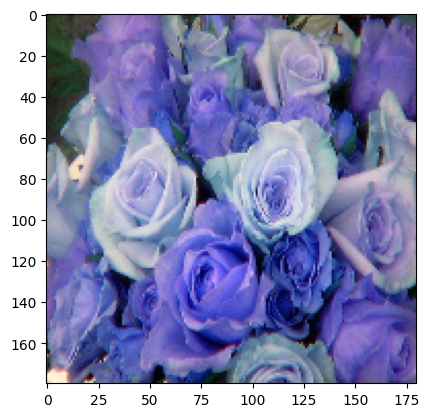

In [28]:
plt.imshow(X[0])

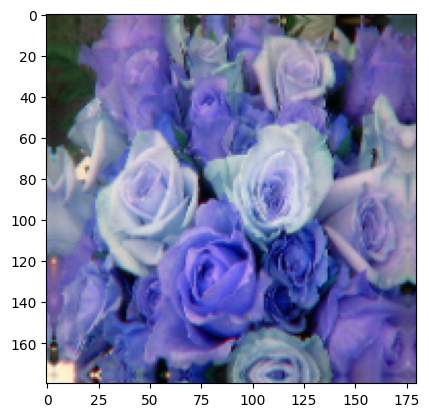

In [29]:
plt.imshow(data_augmentation(X)[0].numpy().astype('uint8'))

In [30]:
# data augmentation to tackle overfitting

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",
                      input_shape=(180, 180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model = Sequential([
    data_augmentation,
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(5)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4444 - loss: 1.3050
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5988 - loss: 1.0197
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6370 - loss: 0.9168
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6650 - loss: 0.8486
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6781 - loss: 0.8120
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7082 - loss: 0.7618
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7198 - loss: 0.7253
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7242 - loss: 0.7137
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7471 - loss: 0.6810
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7576 - loss: 0.6246
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7627 - loss: 0.6017
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy

In [32]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7233 - loss: 1.1538


[1.1537936925888062, 0.7233115434646606]

the model has been improved

In [17]:
# Now we'll see how transfer learning can be used in a model
# it means we'll take another model and applying it to this different but related problem
# this is not working and we'll do it later

import tensorflow_hub as hub
import tensorflow as tf

image_shape = (224,224)

classifier = tf.keras.Sequential([
    hub.KerasLayer('https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4',input_shape=image_shape+(3,))
])

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <tensorflow_hub.keras_layer.KerasLayer object at 0x7edf0e225c40> (of type <class 'tensorflow_hub.keras_layer.KerasLayer'>)

Now, let's add a classification head to the `m` model and compile it for training.

In [ ]:
# Add a classification head
x = tf.keras.layers.Dense(5)(x) # 5 classes for the 5 flower types

# Create the final classification model
classifier_model = tf.keras.Model(inputs=input_tensor, outputs=x)

# Compile the model
classifier_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])